# Self-Supervised / Contrastive Image Similarity

## Learn image similarity without manually labeled pairs

This notebook is a research-style introduction and practical walkthrough of **self-supervised image representation learning** for **image–image similarity matching**.

The core question:

> Can we learn an embedding space where visually or semantically similar images are close, **without manually labeled image pairs**?

We will cover:

1. Why self-supervised learning matters for image matching.
2. The contrastive learning idea: positive pairs, negative pairs, augmentations.
3. Major methods: **SimCLR**, **MoCo**, **BYOL**, **DINO**.
4. A practical implementation of a small SimCLR-style model.
5. How to use learned embeddings for image retrieval.
6. Visualizations: augmentations, similarity matrix, training loss, t-SNE, nearest neighbors.
7. Research questions and possible experiments.

---

## Key papers

| Method | Paper | Venue / Year | Core contribution |
|---|---|---:|---|
| SimCLR | *A Simple Framework for Contrastive Learning of Visual Representations* | ICML 2020 | Strong contrastive baseline using augmentations, projection head, NT-Xent loss |
| MoCo | *Momentum Contrast for Unsupervised Visual Representation Learning* | CVPR 2020 | Queue + momentum encoder for large negative dictionary |
| BYOL | *Bootstrap Your Own Latent* | NeurIPS 2020 | Learns without explicit negative samples |
| DINO | *Emerging Properties in Self-Supervised Vision Transformers* | ICCV 2021 | Self-distillation for ViTs; emergent semantic features |

Useful links:

- SimCLR: https://arxiv.org/abs/2002.05709
- MoCo: https://arxiv.org/abs/1911.05722
- BYOL: https://proceedings.neurips.cc/paper/2020/hash/f3ada80d5c4ee70142b17b8192b2958e-Abstract.html
- DINO: https://openaccess.thecvf.com/content/ICCV2021/html/Caron_Emerging_Properties_in_Self-Supervised_Vision_Transformers_ICCV_2021_paper

# 1. Problem Setting: Image Similarity Without Labels

In supervised image matching, we often need labels such as:

- "same object" vs "different object"
- "same class" vs "different class"
- duplicate / non-duplicate
- matching / non-matching image pairs

But manual pair labels are expensive. If a dataset has `N` images, the possible number of image pairs is roughly:

\[
\frac{N(N-1)}{2}
\]

That grows extremely fast.

Self-supervised learning avoids this by creating **pseudo-pairs automatically**.

The most common trick:

> Take one image, create two different augmented views of it, and treat them as a positive pair.

Example:

- Original image: dog
- View 1: randomly cropped dog image
- View 2: color-jittered dog image

The model is trained to understand that both views still represent the same underlying image.

In [ ]:
import math

def number_of_pairs(n):
    return n * (n - 1) // 2

for n in [100, 1_000, 10_000, 100_000]:
    print(f"{n:>8,} images -> {number_of_pairs(n):>15,} possible pairs")

     100 images ->           4,950 possible pairs
   1,000 images ->         499,500 possible pairs
  10,000 images ->      49,995,000 possible pairs
 100,000 images ->   4,999,950,000 possible pairs


# 2. Taxonomy of Self-Supervised Image Similarity Methods

Self-supervised visual representation learning can be organized like this:

| Family | Main idea | Representative methods |
|---|---|---|
| Instance discrimination / contrastive | Pull augmented views of same image together, push different images apart | SimCLR, MoCo |
| Memory-bank / queue-based contrastive | Maintain many negatives without huge batch size | MoCo |
| Clustering-based | Assign images to pseudo-clusters and learn stable representations | DeepCluster, SwAV |
| Non-contrastive Siamese | Avoid negatives using stop-gradient, predictor, teacher-student setup | BYOL, SimSiam |
| Self-distillation | Student predicts teacher outputs across views | DINO |
| Masked image modeling | Reconstruct missing image regions or tokens | MAE, iBOT |

This notebook focuses mainly on **contrastive and related similarity-learning methods**, because they map most directly to image retrieval.

# 3. Core Concept: Embedding Space

Most image matching systems use this pipeline:

```text
image -> encoder -> embedding vector -> similarity search
```

The goal is to learn an encoder \( f_\theta(x) \) such that:

\[
\text{similar images} \Rightarrow \text{nearby vectors}
\]

\[
\text{different images} \Rightarrow \text{far-apart vectors}
\]

A common similarity score is cosine similarity:

\[
\text{sim}(u, v) = \frac{u \cdot v}{\|u\|\|v\|}
\]

In retrieval, we encode a query image and find database images with the highest cosine similarity.

In [ ]:
import numpy as np

def cosine_similarity(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

u = [1, 2, 3]
v = [1, 2, 2.9]
w = [-1, 0, 0]

print("cos(u, v) =", cosine_similarity(u, v))
print("cos(u, w) =", cosine_similarity(u, w))

cos(u, v) = 0.9998668282478015
cos(u, w) = -0.2672612419124244


# 4. Contrastive Learning Intuition

Contrastive learning creates:

- **Positive pair**: two augmented views of the same image.
- **Negative pairs**: augmented views from different images.

The model learns:

\[
z_i \approx z_j
\]

if \(i\) and \(j\) are two views of the same image.

And:

\[
z_i \not\approx z_k
\]

if \(i\) and \(k\) come from different images.

This is why contrastive learning is useful for image matching: it directly trains the embedding space.

# 5. SimCLR: Simple Contrastive Learning

## Paper

**Ting Chen, Simon Kornblith, Mohammad Norouzi, Geoffrey Hinton.  
"A Simple Framework for Contrastive Learning of Visual Representations." ICML 2020.**

## Problem

How can we learn useful visual representations without labels?

## Core idea

For each image:

1. Create two random augmented views.
2. Pass both views through the same encoder.
3. Use a projection head.
4. Pull embeddings of the same image together.
5. Push embeddings of other images apart.

## Architecture

```text
image x
  ├── augmentation t1 -> view x_i -> encoder f -> representation h_i -> projection head g -> z_i
  └── augmentation t2 -> view x_j -> encoder f -> representation h_j -> projection head g -> z_j
```

## Key findings from the paper

- Strong data augmentation is crucial.
- A nonlinear projection head improves representation quality.
- Larger batch sizes help because they provide more negative samples.
- Longer training helps.

## Limitation

SimCLR usually needs large batch sizes to provide enough negative examples.

# 6. MoCo: Momentum Contrast

## Paper

**Kaiming He, Haoqi Fan, Yuxin Wu, Saining Xie, Ross Girshick.  
"Momentum Contrast for Unsupervised Visual Representation Learning." CVPR 2020.**

## Problem

SimCLR relies heavily on large batch sizes. Can we have many negative samples without making the batch huge?

## Core idea

MoCo treats contrastive learning as a dictionary lookup problem.

It maintains:

- a **query encoder**
- a **key encoder**
- a **queue** of encoded negative examples
- a **momentum update** for the key encoder

## Architecture

```text
query image -> query encoder -> query vector

key image -> momentum key encoder -> key vector

queue = many previous key vectors
```

The queue acts as a large dictionary of negatives.

## Strength

MoCo makes contrastive learning more memory-efficient.

## Limitation

The queue must remain consistent; stale negatives can hurt if the encoder changes too quickly.

# 7. BYOL: Bootstrap Your Own Latent

## Paper

**Jean-Bastien Grill et al.  
"Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning." NeurIPS 2020.**

## Problem

Do we really need negative samples?

## Core idea

BYOL uses two networks:

- **online network**
- **target network**

The online network predicts the target network representation of another augmented view.

Important design components:

- momentum-updated target network
- stop-gradient
- predictor head

## Surprising result

BYOL can learn strong representations without explicit negative examples.

## Why this matters for image matching

It suggests that image similarity can be learned not only by "push apart negatives", but also by learning stable invariances across views.

## Limitation

The reason non-contrastive methods avoid representation collapse is subtle and depends on architectural/training details.

# 8. DINO: Self-Distillation with Vision Transformers

## Paper

**Mathilde Caron et al.  
"Emerging Properties in Self-Supervised Vision Transformers." ICCV 2021.**

## Problem

Can self-supervised learning produce semantic representations in Vision Transformers?

## Core idea

DINO trains a student network to match the output distribution of a teacher network across different image crops.

The teacher is updated using exponential moving average of the student.

## Important finding

DINO ViT features often show strong semantic localization properties. Attention maps can highlight object regions without segmentation labels.

## Why this matters for image retrieval

DINO-style embeddings are often strong general-purpose visual descriptors.

# 9. Setup

This notebook uses PyTorch and torchvision.

It is designed to run in Google Colab or a local Jupyter environment.

For a quick demo, we use **CIFAR-10**, but we ignore the labels during self-supervised training.

Labels are used only later for visualization and evaluation sanity checks.

In [ ]:
# If running in a fresh Colab environment, uncomment:
# !pip install torch torchvision matplotlib scikit-learn tqdm

import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torchvision.models import resnet18

from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import top_k_accuracy_score
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cuda


# 10. Data Augmentation as Automatic Pair Generation

In SimCLR, labels are not needed. Positive pairs are generated by applying two random augmentations to the same image.

Common augmentations:

- random resized crop
- horizontal flip
- color jitter
- grayscale
- Gaussian blur

The exact augmentations matter a lot. If augmentations are too weak, the task becomes trivial. If too strong, the two views may no longer preserve the same semantic content.

In [ ]:
class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        view1 = self.transform(image)
        view2 = self.transform(image)
        return view1, view2, label

contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.4, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
])

plain_transform = transforms.Compose([
    transforms.ToTensor()
])

train_raw = CIFAR10(root="./data", train=True, download=True)
test_raw = CIFAR10(root="./data", train=False, download=True)

# Use a subset for quick demo. Increase this for better results.
subset_size = 5000
indices = list(range(subset_size))
train_subset_raw = Subset(train_raw, indices)

contrastive_dataset = SimCLRDataset(train_subset_raw, contrastive_transform)
contrastive_loader = DataLoader(
    contrastive_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    drop_last=True,
    pin_memory=True if device == "cuda" else False,
)

100%|██████████| 170M/170M [00:03<00:00, 47.6MB/s]


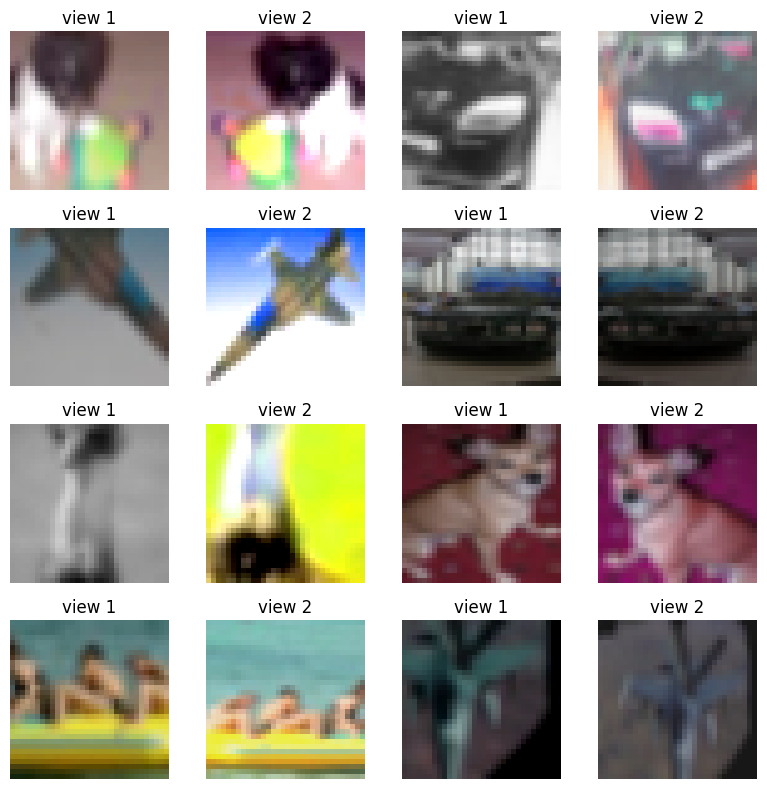

In [ ]:
def imshow_tensor(img, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    img = img.detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title)
    return ax

# Visualize augmented pairs
view1, view2, labels = next(iter(contrastive_loader))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    imshow_tensor(view1[i], axes[i, 0], "view 1")
    imshow_tensor(view2[i], axes[i, 1], "view 2")
    imshow_tensor(view1[i+4], axes[i, 2], "view 1")
    imshow_tensor(view2[i+4], axes[i, 3], "view 2")
plt.tight_layout()
plt.show()

# 11. Encoder + Projection Head

SimCLR separates:

- **representation** \(h\): output of encoder, used for downstream tasks.
- **projection** \(z\): output of projection head, used for contrastive loss.

The projection head is usually discarded after training.

Why?

The paper found that using a projection head improves representation quality. The loss can shape \(z\), while \(h\) remains more useful for downstream tasks.

In [ ]:
class SmallSimCLR(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()

        # ResNet18 modified for CIFAR-sized images.
        self.encoder = resnet18(weights=None)
        self.encoder.conv1 = nn.Conv2d(
            3, 64, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.encoder.maxpool = nn.Identity()

        in_dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        self.projection_head = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(inplace=True),
            nn.Linear(in_dim, projection_dim)
        )

    def forward(self, x, return_representation=False):
        h = self.encoder(x)
        z = self.projection_head(h)
        z = F.normalize(z, dim=1)

        if return_representation:
            return h, z
        return z

model = SmallSimCLR(projection_dim=128).to(device)
print(model)

SmallSimCLR(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        

# 12. NT-Xent Loss

SimCLR uses **Normalized Temperature-scaled Cross Entropy Loss**, often called **NT-Xent**.

For a positive pair \(i, j\):

\[
\ell_{i,j} = - \log \frac{\exp(\text{sim}(z_i,z_j)/\tau)}
{\sum_{k=1}^{2N} \mathbb{1}_{k \ne i} \exp(\text{sim}(z_i,z_k)/\tau)}
\]

Where:

- \(N\): batch size before making two views
- \(2N\): total augmented samples
- \(\tau\): temperature parameter
- \(\text{sim}\): cosine similarity

Intuition:

- numerator: similarity of positive pair
- denominator: similarity to all other candidates
- objective: make the correct positive view easy to identify

In [ ]:
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.size(0)

        z = torch.cat([z1, z2], dim=0)
        sim = torch.matmul(z, z.T) / self.temperature

        # Remove self-similarity from denominator
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        sim = sim.masked_fill(mask, -9e15)

        # Positive pairs:
        # z1[i] positive is z2[i], index i + batch_size
        # z2[i] positive is z1[i], index i
        targets = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(0, batch_size)
        ]).to(z.device)

        loss = F.cross_entropy(sim, targets)
        return loss

criterion = NTXentLoss(temperature=0.5)

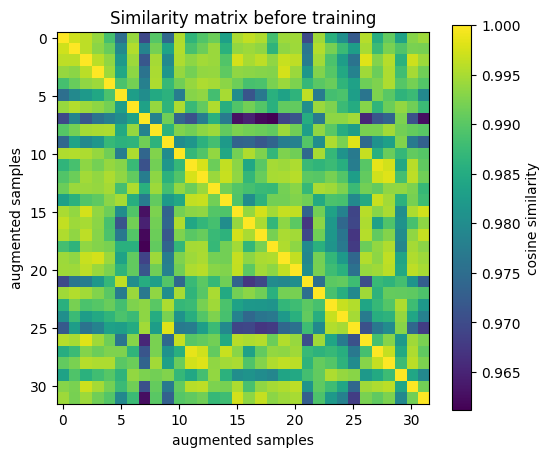

In [ ]:
# Visualize the similarity matrix before training
model.eval()
with torch.no_grad():
    x1 = view1[:16].to(device)
    x2 = view2[:16].to(device)
    z1 = model(x1)
    z2 = model(x2)
    z = torch.cat([z1, z2], dim=0)
    sim_matrix = torch.matmul(z, z.T).cpu().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(sim_matrix)
plt.colorbar(label="cosine similarity")
plt.title("Similarity matrix before training")
plt.xlabel("augmented samples")
plt.ylabel("augmented samples")
plt.show()

# 13. Training a Small SimCLR Model

This is a small educational training run.

For serious research, use:

- larger datasets such as ImageNet, STL-10, COCO, or domain-specific image datasets
- longer training
- stronger encoders
- larger batch size or memory queue
- better augmentations
- distributed training if needed

This demo is intentionally lightweight.

In [ ]:
def train_simclr(model, loader, epochs=5, lr=3e-4, weight_decay=1e-4):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(epochs):
        total_loss = 0.0
        start = time.time()

        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for x1, x2, _ in pbar:
            x1 = x1.to(device, non_blocking=True)
            x2 = x2.to(device, non_blocking=True)

            z1 = model(x1)
            z2 = model(x2)

            loss = criterion(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(loader)
        history.append(avg_loss)
        elapsed = time.time() - start
        print(f"Epoch {epoch+1}: loss={avg_loss:.4f}, time={elapsed:.1f}s")

    return history

# For a quick run, keep epochs small.
# Increase to 50+ for meaningful results.
history = train_simclr(model, contrastive_loader, epochs=5)

Epoch 1/5:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 1: loss=4.7931, time=10.7s


Epoch 2/5:   0%|          | 0/39 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3d402dc9a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3d402dc9a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1655, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():Exception ignored in: 
<function _MultiProcessing

Epoch 2: loss=4.4707, time=11.7s


...

Epoch 3: loss=4.3676, time=11.5s


Epoch 4/5:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 4: loss=4.3141, time=11.3s


Epoch 5/5:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 5: loss=4.2733, time=10.2s


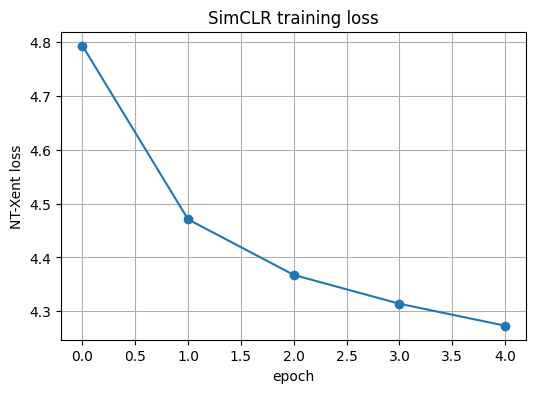

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history, marker="o")
plt.xlabel("epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR training loss")
plt.grid(True)
plt.show()

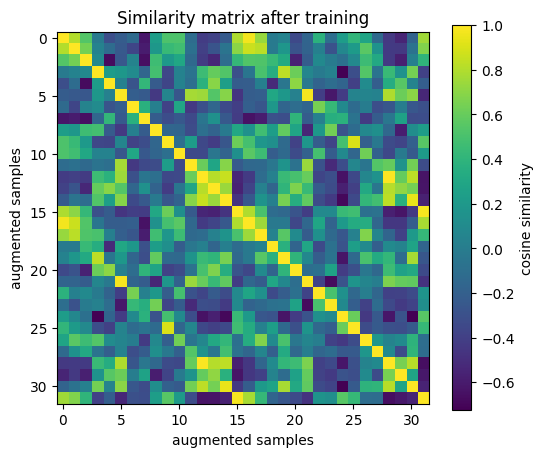

In [ ]:
# Similarity matrix after training
model.eval()
with torch.no_grad():
    x1 = view1[:16].to(device)
    x2 = view2[:16].to(device)
    z1 = model(x1)
    z2 = model(x2)
    z = torch.cat([z1, z2], dim=0)
    sim_matrix = torch.matmul(z, z.T).cpu().numpy()

plt.figure(figsize=(6, 5))
plt.imshow(sim_matrix)
plt.colorbar(label="cosine similarity")
plt.title("Similarity matrix after training")
plt.xlabel("augmented samples")
plt.ylabel("augmented samples")
plt.show()

# 14. Extracting Embeddings for Image Retrieval

After self-supervised training, we use the **encoder representation** \(h\), not the projection \(z\), as the image descriptor.

Retrieval pipeline:

```text
database images -> encoder -> database embeddings
query image -> encoder -> query embedding
nearest neighbor search -> top-k similar images
```

In [ ]:
class PlainCIFARDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        return self.transform(image), label, idx

plain_train = PlainCIFARDataset(train_subset_raw, plain_transform)
plain_loader = DataLoader(
    plain_train,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True if device == "cuda" else False,
)

@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()
    embeddings = []
    labels = []
    indices = []

    for x, y, idx in tqdm(loader, desc="Extracting embeddings"):
        x = x.to(device)
        h, z = model(x, return_representation=True)
        h = F.normalize(h, dim=1)

        embeddings.append(h.cpu().numpy())
        labels.extend(y.numpy().tolist())
        indices.extend(idx.numpy().tolist())

    embeddings = np.concatenate(embeddings, axis=0)
    labels = np.array(labels)
    indices = np.array(indices)
    return embeddings, labels, indices

embeddings, labels, indices = extract_embeddings(model, plain_loader)
print("Embeddings:", embeddings.shape)

Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Embeddings: (5000, 512)


# 15. Nearest Neighbor Search

We use cosine similarity.

Because embeddings are L2-normalized, cosine similarity is equivalent to dot product.

Here we use `sklearn.NearestNeighbors` for simplicity.

For large-scale retrieval, use:

- FAISS
- ScaNN
- Annoy
- Milvus
- Qdrant
- Weaviate

In [ ]:
nn_index = NearestNeighbors(
    n_neighbors=11,
    metric="cosine"
)
nn_index.fit(embeddings)

def retrieve_neighbors(query_position, k=10):
    query_emb = embeddings[query_position:query_position+1]
    distances, neighbor_positions = nn_index.kneighbors(query_emb, n_neighbors=k+1)

    # First neighbor is usually the query itself.
    return distances[0], neighbor_positions[0]

distances, neighbor_positions = retrieve_neighbors(query_position=0, k=10)
print("Neighbor positions:", neighbor_positions)
print("Distances:", distances)
print("Labels:", labels[neighbor_positions])

Neighbor positions: [   0 4831 2607  831 2945 2340 1228 2136 3186  960 2369]
Distances: [0.         0.00822836 0.01101929 0.0113399  0.01138109 0.01267111
 0.01280421 0.01335919 0.01465523 0.01501554 0.01502866]
Labels: [6 6 6 4 5 2 6 2 7 6 6]


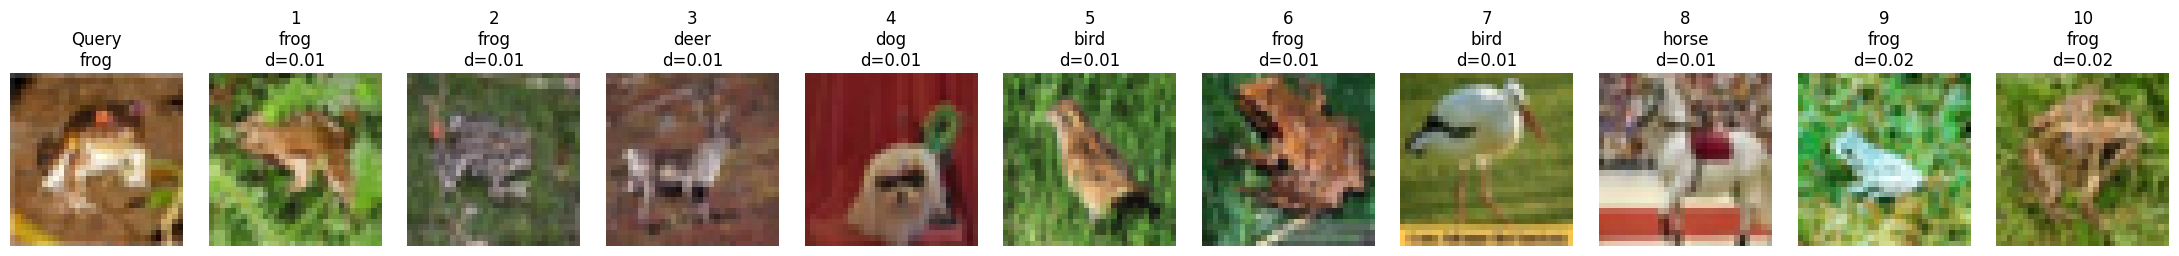

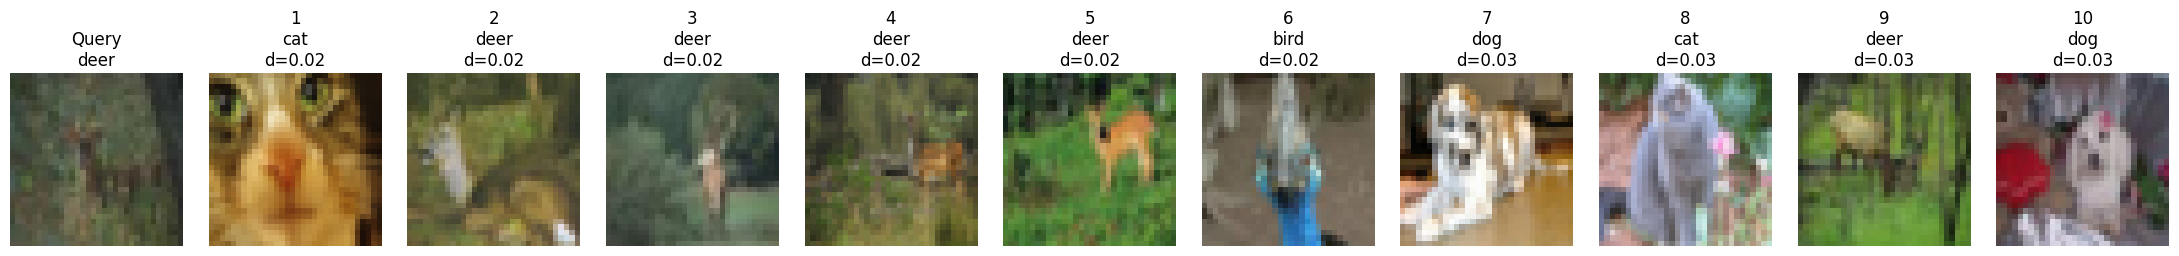

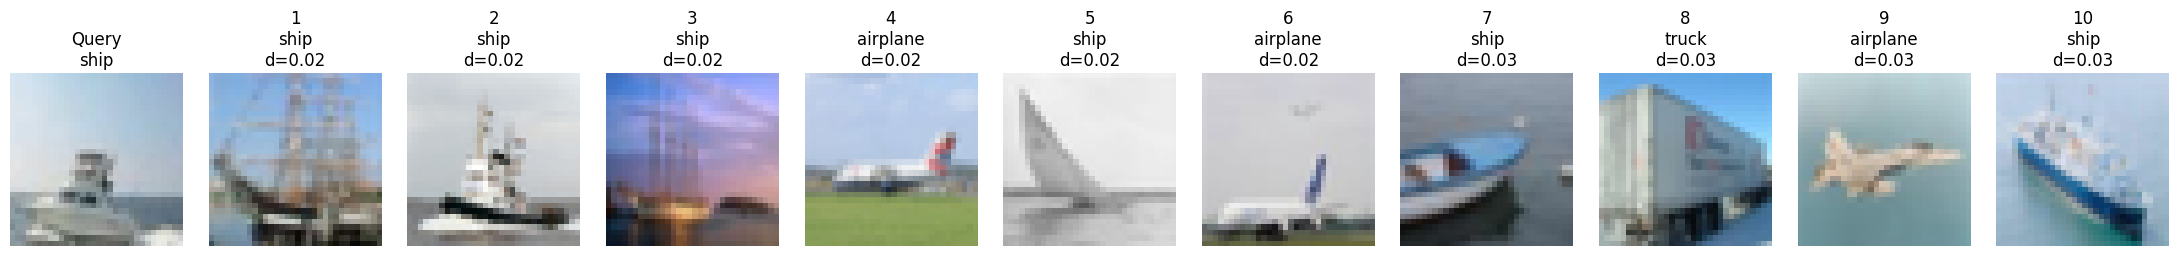

In [ ]:
class_names = train_raw.classes

def get_image_from_subset(position):
    original_idx = indices[position]
    img, label = train_raw[original_idx]
    return img, label

def show_retrieval(query_position, k=10):
    distances, neighbor_positions = retrieve_neighbors(query_position, k=k)

    fig, axes = plt.subplots(1, k + 1, figsize=(2 * (k + 1), 2.4))

    for plot_i, pos in enumerate(neighbor_positions):
        img, label = get_image_from_subset(pos)
        axes[plot_i].imshow(img)
        axes[plot_i].axis("off")

        if plot_i == 0:
            axes[plot_i].set_title(f"Query\n{class_names[label]}")
        else:
            axes[plot_i].set_title(
                f"{plot_i}\n{class_names[label]}\nd={distances[plot_i]:.2f}"
            )

    plt.tight_layout()
    plt.show()

show_retrieval(query_position=0, k=10)
show_retrieval(query_position=10, k=10)
show_retrieval(query_position=100, k=10)

# 16. Retrieval Evaluation Without Pair Labels

Even if self-supervised training ignores labels, CIFAR-10 labels can be used for evaluation.

A simple proxy metric:

> For each query, what fraction of the top-k retrieved images have the same class label?

This is not perfect because image similarity is richer than class labels.  
For example, two different dog images may be same class but visually very different.

Still, it is useful for sanity checking.

In [ ]:
def evaluate_retrieval_precision_at_k(embeddings, labels, k=5, max_queries=1000):
    nn_index = NearestNeighbors(n_neighbors=k+1, metric="cosine")
    nn_index.fit(embeddings)

    query_positions = np.arange(min(max_queries, len(embeddings)))
    distances, neighbors = nn_index.kneighbors(embeddings[query_positions], n_neighbors=k+1)

    # remove self neighbor
    neighbors = neighbors[:, 1:]

    precisions = []
    for qi, neigh in zip(query_positions, neighbors):
        precision = np.mean(labels[neigh] == labels[qi])
        precisions.append(precision)

    return float(np.mean(precisions))

for k in [1, 5, 10]:
    p_at_k = evaluate_retrieval_precision_at_k(embeddings, labels, k=k)
    print(f"Precision@{k}: {p_at_k:.4f}")

Precision@1: 0.2990
Precision@5: 0.2940
Precision@10: 0.2887


# 17. t-SNE Visualization of the Embedding Space

t-SNE gives a 2D view of the learned embeddings.

Important warning:

> t-SNE is useful for visualization, but it is not a reliable quantitative evaluation metric.

Look for rough clustering patterns, not exact geometry.

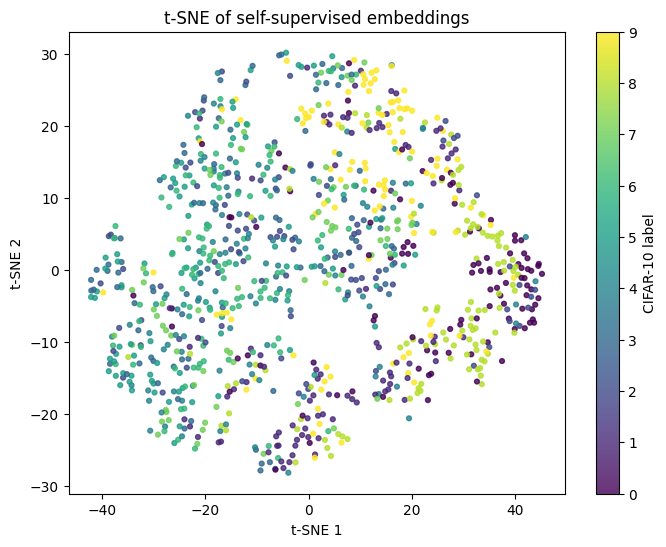

In [ ]:
sample_n = min(1000, len(embeddings))
sample_idx = np.random.choice(len(embeddings), size=sample_n, replace=False)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

emb_2d = tsne.fit_transform(embeddings[sample_idx])
sample_labels = labels[sample_idx]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=sample_labels,
    s=12,
    alpha=0.8
)
plt.colorbar(scatter, ticks=range(10), label="CIFAR-10 label")
plt.title("t-SNE of self-supervised embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

# 18. Compare Against a Random Encoder Baseline

A proper experiment needs a baseline.

Here we compare retrieval quality against an untrained encoder.

If the trained model is working, it should retrieve more same-class images than the random encoder.

In [ ]:
random_model = SmallSimCLR(projection_dim=128).to(device)
random_embeddings, random_labels, random_indices = extract_embeddings(random_model, plain_loader)

print("Random encoder:")
for k in [1, 5, 10]:
    p_at_k = evaluate_retrieval_precision_at_k(random_embeddings, random_labels, k=k)
    print(f"Precision@{k}: {p_at_k:.4f}")

print("\nSelf-supervised encoder:")
for k in [1, 5, 10]:
    p_at_k = evaluate_retrieval_precision_at_k(embeddings, labels, k=k)
    print(f"Precision@{k}: {p_at_k:.4f}")

Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Random encoder:
Precision@1: 0.2850
Precision@5: 0.2616
Precision@10: 0.2498

Self-supervised encoder:
Precision@1: 0.2990
Precision@5: 0.2940
Precision@10: 0.2887


# 19. Practical Research Questions

You can turn this notebook into a research report by investigating questions like these.

## Q1. Which augmentations matter most?

Experiment:

- remove color jitter
- remove random crop
- remove grayscale
- change crop scale

Expected insight:

- Contrastive learning is very sensitive to augmentation design.
- Augmentations define what invariances the model learns.

## Q2. How does batch size affect retrieval quality?

Experiment:

- batch sizes: 32, 64, 128, 256
- compare Precision@K

Expected insight:

- In SimCLR, larger batches provide more negatives.
- Small batches may work poorly unless compensated by a queue or memory bank.

## Q3. Does temperature affect embedding structure?

Experiment:

- temperature: 0.1, 0.2, 0.5, 1.0

Expected insight:

- Lower temperature makes the softmax sharper.
- Too low can make training unstable; too high can weaken contrast.

## Q4. Do projection dimensions matter?

Experiment:

- projection dimensions: 64, 128, 256, 512

Expected insight:

- Projection dimension may affect contrastive optimization.
- Final retrieval should usually use encoder representation \(h\), not projection \(z\).

## Q5. Same class vs true visual similarity

Class labels are limited.

Example:

- A red car and a blue car are same class but visually different.
- A truck and a car may be visually similar but have different labels.

Research direction:

- compare class-based metrics with human similarity judgments.
- evaluate on datasets designed for retrieval.

# 20. Extension: Using Pretrained Self-Supervised Models

Training strong self-supervised models from scratch is expensive.

For real projects, it is common to use pretrained models:

- DINO / DINOv2
- CLIP image encoder
- self-supervised ResNet checkpoints
- MAE-pretrained ViT
- domain-specific foundation models

Example retrieval pipeline with pretrained model:

```text
load pretrained encoder
remove classifier head
extract normalized embeddings
build nearest-neighbor index
retrieve top-k images
evaluate or inspect results
```

For product search, agriculture images, medical images, or industrial inspection, a good strategy is:

1. Start with a pretrained encoder.
2. Evaluate retrieval quality.
3. Fine-tune with contrastive learning on your own unlabeled images.
4. If possible, add a small amount of labeled positive/negative pairs.

# 21. When Should You Use These Methods?

| Situation | Recommended method |
|---|---|
| Small dataset, quick baseline | pretrained CLIP / DINO embeddings |
| Large unlabeled image collection | SimCLR / MoCo / BYOL / DINO-style pretraining |
| Limited GPU memory | MoCo-style queue or pretrained encoder |
| No negative pairs available | BYOL / SimSiam / DINO |
| Need semantic retrieval | DINO / CLIP / ViT-based embeddings |
| Need instance-level matching | SIFT/ORB + deep embeddings, depending on image type |
| Need production-scale search | pretrained encoder + FAISS / vector database |

For image retrieval, do not worship one method like it is a golden buffalo.  
Start simple, measure retrieval quality, then improve the weakest part.

# 22. Summary

Self-supervised and contrastive methods learn image similarity by creating supervision from the data itself.

Main lesson:

> We can learn useful image embeddings without manually labeled pairs by training the model to recognize different augmented views of the same image.

Key methods:

- **SimCLR**: simple and strong, but benefits from large batch sizes.
- **MoCo**: uses a queue and momentum encoder to maintain many negatives.
- **BYOL**: learns without explicit negatives.
- **DINO**: self-distillation, especially powerful with Vision Transformers.

For image matching and retrieval:

1. Train or load an encoder.
2. Extract normalized embeddings.
3. Use cosine similarity or nearest-neighbor search.
4. Evaluate with Precision@K, Recall@K, mAP, or task-specific metrics.
5. Inspect qualitative nearest neighbors.

# 23. References

1. Chen, T., Kornblith, S., Norouzi, M., & Hinton, G.  
   **A Simple Framework for Contrastive Learning of Visual Representations.** ICML 2020.  
   https://arxiv.org/abs/2002.05709

2. He, K., Fan, H., Wu, Y., Xie, S., & Girshick, R.  
   **Momentum Contrast for Unsupervised Visual Representation Learning.** CVPR 2020.  
   https://arxiv.org/abs/1911.05722

3. Grill, J.-B., Strub, F., Altché, F., et al.  
   **Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning.** NeurIPS 2020.  
   https://proceedings.neurips.cc/paper/2020/hash/f3ada80d5c4ee70142b17b8192b2958e-Abstract.html

4. Caron, M., Touvron, H., Misra, I., et al.  
   **Emerging Properties in Self-Supervised Vision Transformers.** ICCV 2021.  
   https://openaccess.thecvf.com/content/ICCV2021/html/Caron_Emerging_Properties_in_Self-Supervised_Vision_Transformers_ICCV_2021_paper

5. Chen, X., & He, K.  
   **Exploring Simple Siamese Representation Learning.** CVPR 2021.  
   https://arxiv.org/abs/2011.10566

6. Caron, M., Misra, I., Mairal, J., Goyal, P., Bojanowski, P., & Joulin, A.  
   **Unsupervised Learning of Visual Features by Contrasting Cluster Assignments.** NeurIPS 2020.  
   https://arxiv.org/abs/2006.09882